---
title: EDA III
---

::: {note} Learning Outcomes
* Write a "For each…" analysis plan and carry it out with `.group_by()` and `.agg()`
* Count rows per group with `.group_by().len()`, and group on more than one column
* Take the top rows of each group with `.sort()` followed by `.group_by().head()`
* Compute percentiles with `.rank()` and split them into equal-sized buckets with `.qcut()`
* Compute a group-wise rate that weights each school by its size
* Find and fill missing values with `.is_null()`, `.fill_null()` and `pl.when()`
* Use the PCS framework's stability check to judge a missing-data decision
:::

We will pick up where EDA II left off: with a plot of four points and the four-row table behind it, which we could describe but not yet build. In this chapter, we will learn to carry out "For each…" analysis plans as grouped operations in Polars and SQL, use them to build that table one step at a time, and then meet our first real decision about missing data.

In [1]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("colorblind")
pl.Config.set_fmt_str_lengths(40)

polars.config.Config

## Where We Left Off

We continue with the UC Berkeley admissions data, joined with the California public schools data. As in EDA I and EDA II, we add each school's application rate and keep the schools whose rate is at most 1.

In [2]:
admissions = pl.read_csv("data/pivoted-ucb-data-w-everything.csv")
admissions = admissions.with_columns(app_rate=pl.col("applied") / pl.col("grade_12"))
admissions = admissions.filter(pl.col("app_rate") <= 1)
admissions

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,"""N""",0.450172,14.878894,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,"""N""",0.469298,41.786639,0.153425
…,…,…,…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,"""N""",0.180556,371.43283,0.210269
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,"""N""",0.479354,148.850295,0.052632
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,"""N""",0.460692,268.05834,0.057554


This is the same table of 1,229 schools and 12 columns that EDA II worked with. In the SQL blocks throughout this chapter, `admissions` names this filtered table, `app_rate` included. When we add a column to the Polars frame, assume the SQL table has it too.

EDA II ended by asking how to generate the four-row table behind its summary plot, and by naming the pattern that most of the answer follows: "For each unique value of COLUMN(S), do SOMETHING." A grouped operation has two parts, the column (or columns) that define the groups, and what we do to each group. In Polars, `.group_by(...)` is the way to say "for each unique value of", and the method that follows it says what to do.

## Grouped Operations

Each question in this section starts as an analysis plan in the form "For each…", written before any code. The plan is the part that takes thought. Once it is clear, the Polars and the SQL follow from it.

### Counting Rows per Group

*Which counties have the most schools?*

**English:** For each unique value of `county`, count the number of rows. Sort in descending order of that count.

`.group_by("county")` splits the table into one group per county. Calling `.len()` on those groups counts the rows in each one, and returns a new table with one row per county: the group key `county` and a count column named `len`. We then sort on `len` as usual.

In [3]:
admissions.group_by("county").len().sort("len", descending=True)

county,len
str,u32
"""Los Angeles""",321
"""San Diego""",94
"""Orange""",77
"""Riverside""",63
"""Alameda""",59
…,…
"""Inyo""",1
"""Trinity""",1
"""Tehama""",1


The result has 54 rows, one per county. Los Angeles leads with 321 schools, followed by San Diego (94) and Orange (77). None of the other columns mattered: to count rows, we only needed to know which county each row belongs to. Counties that tie, like the ones with a single school at the bottom of the table, come out in no fixed order.

The same count can be written with `.agg()`, which is how most grouped computations in this chapter look. `.agg(...)` takes one or more named expressions and evaluates each one once per group. Inside it, `pl.len()` means "the number of rows in this group," and the keyword `num_schools=` names the output column, just as a keyword argument names a new column in `.with_columns()`.

In [4]:
admissions.group_by("county").agg(num_schools=pl.len()).sort("num_schools", descending=True).head(5)

county,num_schools
str,u32
"""Los Angeles""",321
"""San Diego""",94
"""Orange""",77
"""Riverside""",63
"""Alameda""",59


The counts are the same; only the column's name has changed.

**SQL:**

```sql
SELECT county, COUNT(*) AS num_schools
FROM admissions
GROUP BY county
ORDER BY num_schools DESC
```

EDA I counted schools per city with `.value_counts(sort=True)`, and `admissions["county"].value_counts(sort=True)` gives these same county counts. `.value_counts()` is a shortcut for this one grouped operation. `.group_by()` is the general tool, and the rest of this chapter needs it.

A related but different question is *how many* counties there are. That asks for the number of distinct values in one column, and `.n_unique()` gives it directly for a `Series`:

In [5]:
admissions["county"].n_unique()

54

There are 54 counties, which is also the number of rows in the grouped table. The two agree because each county gets exactly one row, but they answer different questions. `.n_unique()` asks "how many groups are there?", while `.group_by(...).len()` asks "how many rows are in each group?"

### Aggregating a Column Within Each Group

Counting rows is only one thing we can do to a group. To see the others on a table small enough to check by hand, we use six purchases from a store. `pl.DataFrame({...})` builds a `DataFrame` from a Python dictionary: each key becomes a column name, and each list becomes that column's values, in order.

In [6]:
transactions = pl.DataFrame(
    {
        "customer_id": ["A", "B", "B", "A", "A", "B"],
        "date": ["6/1", "6/1", "6/1", "6/2", "6/2", "6/2"],
        "cost": [10, 50, 10, 20, 100, 30],
    }
)
transactions

customer_id,date,cost
str,str,i64
"""A""","""6/1""",10
"""B""","""6/1""",50
"""B""","""6/1""",10
"""A""","""6/2""",20
"""A""","""6/2""",100
"""B""","""6/2""",30


Each row is one purchase: who made it, on which day, and how much it cost.

*Which customers spend the most money?*

**English:** For each `customer_id`, sum up the `cost` column. Sort in descending order of the summed cost.

EDA I called `.min()` on a whole `Series`. The same aggregation methods, including `.sum()` and `.mean()`, also work on an expression such as `pl.col("cost")`. Inside `.agg()`, the expression is computed separately for each group, so `pl.col("cost").sum()` gives one total per customer.

In [7]:
transactions.group_by("customer_id").agg(total_cost=pl.col("cost").sum()).sort("total_cost", descending=True)

customer_id,total_cost
str,i64
"""A""",130
"""B""",90


Customer A spent 130 and customer B spent 90. Each column of the result is either a group key (`customer_id`) or something we named inside `.agg()` (`total_cost`). The `date` column is gone, because we did not say what to do with it.

**SQL:**

```sql
SELECT customer_id, SUM(cost) AS total_cost
FROM transactions
GROUP BY customer_id
ORDER BY total_cost DESC
```

::: {tip} Say what to aggregate
Polars also has shortcuts such as `transactions.group_by("customer_id").sum()`, which sums every column that is not a group key. On this table, that raises an `InvalidOperationError`, because `date` holds strings and strings cannot be summed. Naming the columns you want inside `.agg()` avoids the problem and lets you choose each output column's name.
:::

### The First Rows of Each Group

EDA I used `.head(n)` to preview the first `n` rows of a table:

In [8]:
admissions.head(3)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,"""N""",0.685365,372.941684,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,"""Y""",0.678421,52.249325,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,"""N""",0.832272,346.780088,0.198347


**SQL:**

```sql
SELECT *
FROM admissions
LIMIT 3
```

`.head(n)` has a second use. On a grouped table, it takes the first `n` rows of *each* group.

*In each county, which two schools admitted the most students?*

**English:** First, sort the entire table in decreasing order of `admitted`. Then, for each unique value of `county`, take the first two rows.

The code needs two details that the plan leaves out. First, `admitted` has nulls, and Polars puts nulls first when it sorts, so we pass `nulls_last=True` as in EDA I. Second, some schools in the same county admitted the same number of students, and when two rows tie, `.sort()` does not promise which one comes first. So we sort on two keys. Rows are ordered by the first key, `admitted`, and ties are broken by the second, `school`. With several keys, `descending=` takes one flag per key.

In [9]:
top_two = (
    admissions.sort("admitted", "school", descending=[True, False], nulls_last=True)
    .group_by("county")
    .head(2)
    .sort("county", "admitted", "school", descending=[False, True, False], nulls_last=True)
)
top_two

county,school,city,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate
str,str,str,i64,i64,i64,i64,i64,str,f64,f64,f64
"""Alameda""","""BERKELEY HIGH SCHOOL""","""Berkeley""",319,73,37,3220,797,"""N""",0.218323,0.682117,0.400251
"""Alameda""","""MISSION SAN JOSE HIGH SCHOOL""","""Fremont""",316,43,28,1822,475,"""N""",0.08562,28.848173,0.665263
"""Amador""","""AMADOR HIGH SCHOOL""","""Sutter Creek""",8,null,null,627,148,"""N""",0.398724,86.77842,0.054054
"""Amador""","""ARGONAUT HIGH SCHOOL""","""Jackson""",7,null,null,594,136,"""N""",0.387205,86.444578,0.051471
"""Butte""","""CHICO HIGH SCHOOL""","""Chico""",43,4,4,1873,504,"""N""",0.44047,130.682756,0.085317
…,…,…,…,…,…,…,…,…,…,…,…
"""Ventura""","""NEWBURY PARK HIGH SCHOOL""","""Newbury Park""",80,11,5,2080,565,"""N""",0.170673,314.614399,0.141593
"""Yolo""","""DAVIS SENIOR HIGH SCHOOL""","""Davis""",225,22,14,1789,605,"""N""",0.181107,54.694817,0.371901
"""Yolo""","""PIONEER HIGH SCHOOL""","""Woodland""",36,6,null,1635,397,"""N""",0.522936,61.044677,0.09068


The last `.sort()` is only for display. `.group_by()` does not keep its groups in any particular order, so we put the counties in alphabetical order, and each county's schools by `admitted`.

The result has 101 rows: two for each of the 54 counties, except the seven counties that have only one school. In Alameda County, BERKELEY HIGH SCHOOL (73 admits) and MISSION SAN JOSE HIGH SCHOOL (43) come first. At the bottom of the table, both Yuba County schools admitted 3 students, and the `school` key decides the order of ties like this one.

Notice that all 12 columns are kept. `.agg()` returns only the group keys and the columns we name, while `.head()` returns whole rows, with the group key `county` moved to the front. `.head()` takes the rows of each group in the order they had before grouping, which is why the sort comes first.

To see what `nulls_last=True` protects us from, we can run the chain without it and count the null values of `admitted` among the rows it keeps. `.null_count()` counts the nulls in a column; we will lean on it later in this chapter. The cell prints two counts, first without `nulls_last=True` and then with it.

In [10]:
without_nulls_last = admissions.sort("admitted", descending=True).group_by("county").head(2)
without_nulls_last["admitted"].null_count(), top_two["admitted"].null_count()

(95, 22)

::: {tip} Nulls sort first
Without `nulls_last=True`, 95 of the 101 rows are schools with a null `admitted`. In every county with at least two such schools, the nulls sort to the top and `.head(2)` takes them. Even with `nulls_last=True`, 22 rows are null. Some counties have fewer than two schools with a reported admit count, and in 12 counties, Amador for one, no school has one at all. We come back to these nulls later in this chapter.
:::

::: {note} Top rows per group in SQL
There is no direct SQL counterpart to `.group_by(...).head(n)`. `GROUP BY` collapses each group into a single row, so it cannot return two whole rows per county. The query below uses a *window function*, `ROW_NUMBER()`, which numbers the rows within each county in the order given, and DuckDB's `QUALIFY` clause keeps the rows numbered 1 and 2. We show it for reference only: window functions are beyond what Data 100 asks you to write.

```sql
SELECT *
FROM admissions
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY county
    ORDER BY admitted DESC NULLS LAST, school
) <= 2
ORDER BY county, admitted DESC NULLS LAST, school
```
:::

### Grouping on More Than One Column

*How much did each customer spend on each day?*

**English:** For each unique combination of `customer_id` and `date`, sum up the `cost` column.

Passing two column names to `.group_by()` makes each group a unique *combination* of their values. Customer A on 6/1 is one group, and customer A on 6/2 is another.

In [11]:
daily_totals = transactions.group_by("customer_id", "date").agg(total_cost=pl.col("cost").sum())
daily_totals.sort("date", "customer_id")

customer_id,date,total_cost
str,str,i64
"""A""","""6/1""",10
"""B""","""6/1""",60
"""A""","""6/2""",120
"""B""","""6/2""",30


Four combinations appear in the data, so the result has four rows. Customer A spent 10 on 6/1 and 120 on 6/2, while customer B spent 60 on 6/1 and 30 on 6/2.

**SQL:**

```sql
SELECT customer_id, date, SUM(cost) AS total_cost
FROM transactions
GROUP BY customer_id, date
ORDER BY date, customer_id
```

### Grouping Twice

*Which customer spent the most money on each day?*

**English:** For each unique combination of `date` and `customer_id`, sum up the `cost` column. Then, sort the result in decreasing order of summed cost. Finally, for each unique `date`, take the first row.

The first step is `daily_totals`, which we just computed. The rest is the recipe from the county question: sort, group, then take the head of each group.

In [12]:
daily_totals.sort("total_cost", descending=True).group_by("date").head(1).sort("date")

date,customer_id,total_cost
str,str,i64
"""6/1""","""B""",60
"""6/2""","""A""",120


On 6/1, customer B spent the most (60), and on 6/2, customer A did (120). The second `.group_by()` does not remember the first. It throws away the groups of customer and date and defines new groups by `date` alone.

::: {note} Grouping twice in SQL
In SQL, this is again a window function, now applied to the grouped result. As with the county example, it is here for reference only.

```sql
SELECT date, customer_id, SUM(cost) AS total_cost
FROM transactions
GROUP BY customer_id, date
QUALIFY ROW_NUMBER() OVER (PARTITION BY date ORDER BY total_cost DESC) = 1
ORDER BY date
```
:::

## Building the FRL Table

### A Three-Step Plan

We now have the tools to answer EDA II's question. The target is a tidy table with one row per point in the plot and one column per feature: four rows, one for each FRL bucket, and two columns, `frl_percentile` and `avg_app_rate`. Our data has one row per school, so we need a plan to get from one to the other:

1. Compute the FRL percentile of each school.
2. Put each school into one of four buckets: `0-25`, `25-50`, `50-75` and `75-100`.
3. For each unique FRL bucket, compute the application rate.

Only step 3 is a grouped operation. Steps 1 and 2 build the column that step 3 groups by.

A plan at this level of detail is also a good first message to an LLM. You supply the plan, which takes an understanding of the data and of what a percentile is. The LLM can supply syntax you do not need to memorize, such as how to compute a percentile in Polars. Your job is then to check what comes back, and the next step shows why.

### Step 1: Percentiles with `.rank()`

A school's FRL percentile is the fraction of schools whose `pct_free_reduced` is at or below its own. If we number the schools 1, 2, …, n from the lowest `pct_free_reduced` to the highest, a school's percentile is its number divided by n. `pl.col(...).rank()` does the numbering: the smallest value gets rank 1, and tied values share the average of their ranks. A null is not ranked, and stays null.

The only question is what n should be. Asked for this computation, an LLM suggested dividing by `pl.count()`, an older name for `pl.len()` that Polars has since deprecated. `pl.len()` counts every row. Let's try it, and look at the result with `.describe()`.

In [13]:
admissions.with_columns(
    frl_percentile_raw=pl.col("pct_free_reduced").rank() / pl.len()
).select("frl_percentile_raw").describe()

statistic,frl_percentile_raw
str,f64
"""count""",1173.0
"""null_count""",56.0
"""mean""",0.477624
"""std""",0.275639
"""min""",0.000814
"""25%""",0.239219
"""50%""",0.476404
"""75%""",0.716029
"""max""",0.954434


Does this column pass the "sniff" test? In other words, does it look correct? The school with the highest FRL share should sit at the top percentile, 1.0, but the maximum is only 0.954. The `count` and `null_count` rows explain why. Only 1,173 schools have a `pct_free_reduced` value to rank, and 56 do not. `pl.len()` counted all 1,229 rows, so the highest rank is 1,173 while the denominator is 1,229, and 1,173 / 1,229 is about 0.954.

What we want is the number of schools that *have* a value. `pl.col("pct_free_reduced").count()` counts the non-null values in the column, so it is the right denominator.

In [14]:
admissions = admissions.with_columns(
    frl_percentile_raw=pl.col("pct_free_reduced").rank() / pl.col("pct_free_reduced").count()
)
admissions.select("frl_percentile_raw").describe()

statistic,frl_percentile_raw
str,f64
"""count""",1173.0
"""null_count""",56.0
"""mean""",0.500426
"""std""",0.288798
"""min""",0.000853
"""25%""",0.250639
"""50%""",0.499147
"""75%""",0.750213
"""max""",1.0


Now the maximum is 1.0 and the median is 0.499, as a percentile's should be. The difference between the two denominators is worth remembering: `pl.len()` counts rows, and `.count()` counts the values that are present. A glance at the minimum and maximum was enough to catch the mistake.

We give no SQL for this step. The SQL in the next step covers steps 1 and 2 together.

### Step 2: Buckets with `.qcut()`

To sort the schools into four buckets, we use `.qcut()`, which cuts a column at its quantiles. `.qcut(4, labels=[...])` finds the three values that split the column into four groups of (nearly) equal size, and gives each group the matching label.

`.qcut()` returns a *categorical* column, a type for labels drawn from a fixed set. We convert the labels to ordinary strings with `.cast(pl.String)`. EDA II used `.cast(int)` to change a column's type, and `pl.String` is Polars' type for text. As plain strings, our labels sort in the order we want (`0-25`, `25-50`, `50-75`, `75-100`), and seaborn plots them without trouble.

**English:** Put each school into one of four equal-sized buckets by its FRL percentile. Then, for each bucket, count the schools and find the lowest and highest `pct_free_reduced`.

In [15]:
admissions = admissions.with_columns(
    frl_percentile=pl.col("frl_percentile_raw")
    .qcut(4, labels=["0-25", "25-50", "50-75", "75-100"])
    .cast(pl.String)
)
(
    admissions.group_by("frl_percentile")
    .agg(
        num_schools=pl.len(),
        lowest=pl.col("pct_free_reduced").min(),
        highest=pl.col("pct_free_reduced").max(),
    )
    .sort("frl_percentile", nulls_last=True)
)

frl_percentile,num_schools,lowest,highest
str,u32,f64,f64
"""0-25""",294,0.034247,0.340791
"""25-50""",293,0.340923,0.562603
"""50-75""",293,0.562701,0.734127
"""75-100""",293,0.734253,0.985318
null,56,null,null


The four buckets hold 294, 293, 293 and 293 schools, a quarter of the ranked schools each. The 56 schools with no `pct_free_reduced` have no percentile, so they land in a fifth group whose key is `null`.

The `lowest` and `highest` columns make EDA II's caution concrete. The `0-25` bucket runs from 0.034 up to 0.341, so it is the quarter of schools with the lowest FRL share, *not* the schools whose `pct_free_reduced` is below 0.25. That is how `.qcut()` creates its bins: by position in the sorted column, so that every bucket holds the same number of schools, however wide or narrow its range of values.

A percentile keeps the schools in the same order as `pct_free_reduced`, so applying `.qcut(4, ...)` to `pct_free_reduced` directly would put each of the 1,173 schools in the same bucket it gets here. The percentile column is there so that we can read it and check it.

**SQL:**

In SQL, the window function `NTILE(4)` splits ordered rows into four equal-sized groups. It numbers the groups 1 to 4 instead of labelling them. Left alone, it would also count the 56 null rows, placing them in the last group, which is the same denominator mistake as in step 1. So we remove them first with `WHERE pct_free_reduced IS NOT NULL`, SQL's test for a value that is present.

The query comes in two layers. The one in parentheses runs first: it keeps the schools that have a value and numbers each into a bucket. The outer query then treats that result as a table and groups it by `frl_bucket`. The two steps have to be separate, because SQL cannot `GROUP BY` a window function in the same `SELECT` that computes it.

```sql
SELECT frl_bucket,
       COUNT(*) AS num_schools,
       MIN(pct_free_reduced) AS lowest,
       MAX(pct_free_reduced) AS highest
FROM (
    SELECT pct_free_reduced,
           NTILE(4) OVER (ORDER BY pct_free_reduced) AS frl_bucket
    FROM admissions
    WHERE pct_free_reduced IS NOT NULL
)
GROUP BY frl_bucket
ORDER BY frl_bucket
```

Bucket 1 is `0-25`, bucket 2 is `25-50`, and so on. Each school lands in the same bucket either way.

### Step 3: Group-Wise Rates, Weighted by School Size

Here is what each school's row now holds:

In [16]:
admissions.select(
    "school", "city", "pct_free_reduced", "frl_percentile_raw", "frl_percentile", "applied", "grade_12", "app_rate"
).head(5)

school,city,pct_free_reduced,frl_percentile_raw,frl_percentile,applied,grade_12,app_rate
str,str,f64,f64,str,i64,i64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""",0.685365,0.670077,"""50-75""",25,485,0.051546
"""ABLE CHARTER""","""Stockton""",0.678421,0.658994,"""50-75""",8,73,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""",0.832272,0.882353,"""75-100""",48,242,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""",0.450172,0.368286,"""25-50""",201,489,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""",0.469298,0.386189,"""25-50""",56,365,0.153425


ABRAHAM LINCOLN HIGH SCHOOL in San Francisco, at percentile 0.368, is in the `25-50` bucket, while the school of the same name in Los Angeles, at 0.882, is in `75-100`.

*How should we compute the application rate within each bucket?*

The tempting answer is to average the `app_rate` column, but we should not. A school with 10 seniors probably should not carry the same weight as one with 1,000. The application rate of a bucket is the share of all its 12th graders who applied: total applicants divided by total possible applicants.

**English:** For each FRL bucket, sum up the `applied` column, sum up the `grade_12` column, and divide.

Before grouping, we drop the 56 schools with no bucket. `.is_not_null()`, which EDA I mentioned in passing, is `True` for each row whose value is present, so filtering on it keeps exactly the schools that have a bucket. Without the filter, `.group_by()` would treat `null` as a key of its own, as it did in the bucket counts above, and compute a fifth row. We keep the filtered table as `binned`, because the rest of this chapter works with the same 1,173 schools.

Alongside the pooled rate `avg_app_rate`, the code also computes `mean_app_rate`, the plain average of `app_rate`, so that we can see what the weighting changes.

In [17]:
binned = admissions.filter(pl.col("frl_percentile").is_not_null())
app_by_frl = (
    binned.group_by("frl_percentile")
    .agg(
        applied=pl.col("applied").sum(),
        grade_12=pl.col("grade_12").sum(),
        avg_app_rate=pl.col("applied").sum() / pl.col("grade_12").sum(),
        mean_app_rate=pl.col("app_rate").mean(),
    )
    .sort("frl_percentile")
)
app_by_frl

frl_percentile,applied,grade_12,avg_app_rate,mean_app_rate
str,i64,i64,f64,f64
"""0-25""",31121,121468,0.256207,0.260226
"""25-50""",12357,105392,0.117248,0.134318
"""50-75""",8618,98652,0.087358,0.108812
"""75-100""",7573,80668,0.093879,0.122906


In the `0-25` bucket, 31,121 of 121,468 12th graders applied, so `avg_app_rate` is 0.256. It falls to 0.117 and 0.087 in the next two buckets, then rises slightly to 0.094. These are the four values behind EDA II's plot.

The unweighted `mean_app_rate` is higher in every bucket: 0.260, 0.134, 0.109 and 0.123. An average that counts every school equally comes out higher than one weighted by the size of the 12th-grade class, which means that within each bucket, the smaller schools tend to have the higher application rates. The gap is widest in the two highest-FRL buckets.

**SQL:**

```sql
SELECT frl_percentile,
       SUM(applied) AS applied,
       SUM(grade_12) AS grade_12,
       SUM(applied) / SUM(grade_12) AS avg_app_rate,
       AVG(app_rate) AS mean_app_rate
FROM admissions
WHERE frl_percentile IS NOT NULL
GROUP BY frl_percentile
ORDER BY frl_percentile
```

### Recreating the Plot

With one row per point, the plot is a single call. `sns.pointplot` draws one point for each category on the x-axis and connects the points with a line. `order=` fixes the left-to-right order of the categories, and `marker=""` hides the point markers so that only the line remains.

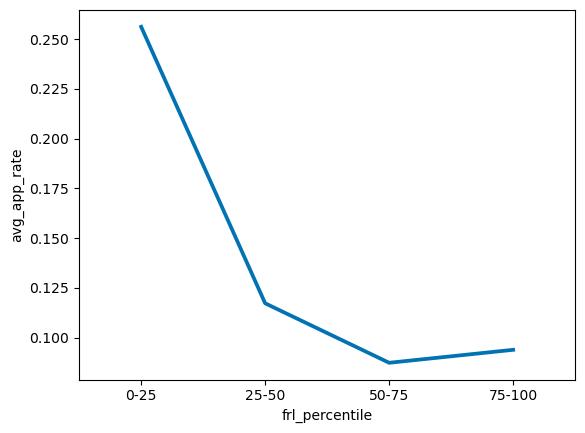

In [18]:
#| fig-alt: Line plot of the application rate in each of four FRL-percentile buckets. The line falls steeply from 0.256 at 0-25 to 0.117 at 25-50, falls again to 0.087 at 50-75, then rises slightly to 0.094 at 75-100.
sns.pointplot(app_by_frl, x="frl_percentile", y="avg_app_rate", order=["0-25", "25-50", "50-75", "75-100"], marker="");

Seaborn draws exactly what the table holds: four points, from 0.256 down to 0.087 and back up to 0.094. The tidy table was the hard part.

## Missing Data

### Admission Rates and the Nulls in `admitted`

Applying is only the first step on the road to Berkeley. *What is the admission rate in each FRL bucket?*

Naively, it is total admits divided by total applicants in each bucket. But the `admitted` column has many nulls. `.null_count()`, which we used on a single column earlier, also works on a whole `DataFrame`, where it returns one row holding the number of nulls in every column.

In [19]:
admissions.null_count()

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,is_charter,pct_free_reduced,dist_to_ucb_miles,app_rate,frl_percentile_raw,frl_percentile
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,418,740,0,0,0,56,0,0,56,56


Of the 1,229 schools, 418 have a null `admitted` and 740 a null `attended`. Among the 1,173 schools that have a bucket, the number with a null `admitted` is:

In [20]:
binned["admitted"].null_count()

391

That is 391 schools. Here are the first few rows of the three count columns:

In [21]:
admissions.select("school", "applied", "admitted", "attended").head(5)

school,applied,admitted,attended
str,i64,i64,i64
"""A B MILLER HIGH SCHOOL""",25,3,null
"""ABLE CHARTER""",8,null,null
"""ABRAHAM LINCOLN HIGH SCHOOL""",48,11,4
"""ABRAHAM LINCOLN HIGH SCHOOL""",201,33,23
"""ABRAHAM LINCOLN HIGH SCHOOL""",56,8,3


ABLE CHARTER had 8 applicants and a null admit count, and A B MILLER HIGH SCHOOL had 3 admits and a null `attended`.

Why are these values missing? As EDA I explained, the UC leaves a count blank when it is below three, so that no individual student can be identified. The smallest admit count that does appear in the data agrees:

In [22]:
admissions["admitted"].min()

3

So a null `admitted` is not a complete unknown. It means 0, 1 or 2.

We will compute the same kind of table several times in this chapter, so we wrap the steps in a function. `admission_rates` takes a table and returns its admission rate in each bucket: total admits divided by total applicants.

In [23]:
def admission_rates(df):
    return (
        df.group_by("frl_percentile")
        .agg(admission_rate=pl.col("admitted").sum() / pl.col("applied").sum())
        .sort("frl_percentile")
    )


admission_rates(binned)

frl_percentile,admission_rate
str,f64
"""0-25""",0.121815
"""25-50""",0.121146
"""50-75""",0.137387
"""75-100""",0.134029


The naive rates are 0.122, 0.121, 0.137 and 0.134.

The code ran without complaint, but it has already made a decision. `.sum()` skips nulls, so each of the 391 schools with a null `admitted` added its applicants to the denominator and nothing to the numerator. That is the same as treating every null as 0, and we will see below that replacing the nulls with 0 gives exactly these four numbers. **Not choosing is a choice.**

Handling missing data is one of the most consequential tasks of a data scientist. Here are several options:

1. Ignore the schools with a null `admitted` when computing admission rates.
2. Replace each null with 0, the smallest possible value.
3. Replace each null with 2, the largest possible value.
4. Replace each null with 0, 1 or 2, chosen at random.

We should not blindly choose one option and move on. Instead, we compute all four.

### Four Ways to Fill In `admitted`

Each option starts from `binned` and ends with `admission_rates`. Only the step in the middle changes.

**Option 1: ignore the nulls.**

**English:** Keep only the schools whose `admitted` is not null, then compute each bucket's admission rate.

In [24]:
ignore_null = binned.filter(pl.col("admitted").is_not_null())
ignore_rates = admission_rates(ignore_null)
ignore_rates

frl_percentile,admission_rate
str,f64
"""0-25""",0.126628
"""25-50""",0.140577
"""50-75""",0.171594
"""75-100""",0.17643


**SQL:**

```sql
SELECT frl_percentile, SUM(admitted) / SUM(applied) AS admission_rate
FROM admissions
WHERE frl_percentile IS NOT NULL AND admitted IS NOT NULL
GROUP BY frl_percentile
ORDER BY frl_percentile
```

**Option 2: replace the nulls with 0.**

`.fill_null(value)` replaces every null in a column with `value` and leaves the other values alone. Naming the result `admitted` inside `.with_columns()` replaces the existing column, rather than adding a new one.

**English:** Replace each null `admitted` with 0, then compute each bucket's admission rate.

In [25]:
replace_0 = binned.with_columns(admitted=pl.col("admitted").fill_null(0))
replace_0_rates = admission_rates(replace_0)
replace_0_rates

frl_percentile,admission_rate
str,f64
"""0-25""",0.121815
"""25-50""",0.121146
"""50-75""",0.137387
"""75-100""",0.134029


These are exactly the naive rates from before: 0.122, 0.121, 0.137 and 0.134.

**SQL:** `COALESCE(admitted, 0)` returns `admitted` when it is present and 0 otherwise.

```sql
SELECT frl_percentile, SUM(COALESCE(admitted, 0)) / SUM(applied) AS admission_rate
FROM admissions
WHERE frl_percentile IS NOT NULL
GROUP BY frl_percentile
ORDER BY frl_percentile
```

**Option 3: replace the nulls with 2.**

**English:** Replace each null `admitted` with 2, then compute each bucket's admission rate.

In [26]:
replace_2 = binned.with_columns(admitted=pl.col("admitted").fill_null(2))
replace_2_rates = admission_rates(replace_2)
replace_2_rates

frl_percentile,admission_rate
str,f64
"""0-25""",0.124964
"""25-50""",0.138626
"""50-75""",0.164307
"""75-100""",0.165192


**SQL:**

```sql
SELECT frl_percentile, SUM(COALESCE(admitted, 2)) / SUM(applied) AS admission_rate
FROM admissions
WHERE frl_percentile IS NOT NULL
GROUP BY frl_percentile
ORDER BY frl_percentile
```

**Option 4: replace the nulls with a random 0, 1 or 2.**

This option needs a different value for each null. `pl.when(condition).then(a).otherwise(b)` is a row-by-row if/else: where the condition is true, it takes the value from `a`, and everywhere else from `b`. Our condition is `pl.col("admitted").is_null()`, the opposite of `.is_not_null()`, which is `True` where the value is missing.

For `a`, we draw one random integer for every row. `np.random.default_rng(7342)` creates a NumPy random number generator with a fixed *seed*, 7342, and `rng.integers(0, 3, size=binned.height)` draws `binned.height` integers from 0, 1 and 2 (the upper bound, 3, is excluded). `pl.Series(...)` wraps that NumPy array as a Polars column. A row whose `admitted` is present simply ignores its draw. The seed makes the draw come out the same every time the notebook runs, so the numbers on this page are reproducible.

**English:** Replace each null `admitted` with a random choice of 0, 1 or 2, then compute each bucket's admission rate.

In [27]:
rng = np.random.default_rng(7342)
replace_r = binned.with_columns(
    admitted=pl.when(pl.col("admitted").is_null())
    .then(pl.Series(rng.integers(0, 3, size=binned.height)))
    .otherwise(pl.col("admitted"))
)
random_rates = admission_rates(replace_r)
random_rates

frl_percentile,admission_rate
str,f64
"""0-25""",0.123421
"""25-50""",0.129319
"""50-75""",0.152007
"""75-100""",0.148686


With this seed, the rates are 0.123, 0.129, 0.152 and 0.149.

**SQL:** SQL writes an if/else as `CASE WHEN … THEN … ELSE … END`, and `FLOOR(RANDOM() * 3)` draws a random 0, 1 or 2. The query below has the same shape as the Polars code, but its numbers will not match ours: `RANDOM()` is DuckDB's own random number generator, so it draws different values.

```sql
SELECT frl_percentile,
       SUM(CASE WHEN admitted IS NULL THEN FLOOR(RANDOM() * 3) ELSE admitted END)
           / SUM(applied) AS admission_rate
FROM admissions
WHERE frl_percentile IS NOT NULL
GROUP BY frl_percentile
ORDER BY frl_percentile
```

### Stability: The PCS Framework

We now have four answers to one question. How should we weigh them? The **Predictability, Computability, and Stability (PCS)** framework was developed by Bin Yu at UC Berkeley and her collaborators for producing trustworthy data analyses. It asks three questions of an analysis:

* **Predictability:** Are the outputs of the analysis consistent with reality and with domain knowledge? The sniff tests in this chapter are checks of this kind.
* **Computability:** Are the results generated by reproducible code? A notebook that runs from top to bottom, with a seeded random draw, gives us this.
* **Stability:** How sensitive is the analysis to realistic changes in its data, or in the decisions made along the way?

Our four options make a stability check: does the pattern in admission rates change with our missing-data approach?

To compare the four patterns fairly, we draw them in a grid of four panels. `plt.subplots(2, 2, sharey=True)` creates the grid, and `sharey=True` gives every panel the same y-axis range, so a small change in one panel looks as small as it is. (`figsize=` sets the figure's width and height in inches.) `axes[row, column]` picks out one panel, which we pass to seaborn with `ax=` and label with `.set_title(...)`. A short loop draws the four panels, and `plt.tight_layout()` spaces them so that their labels do not overlap.

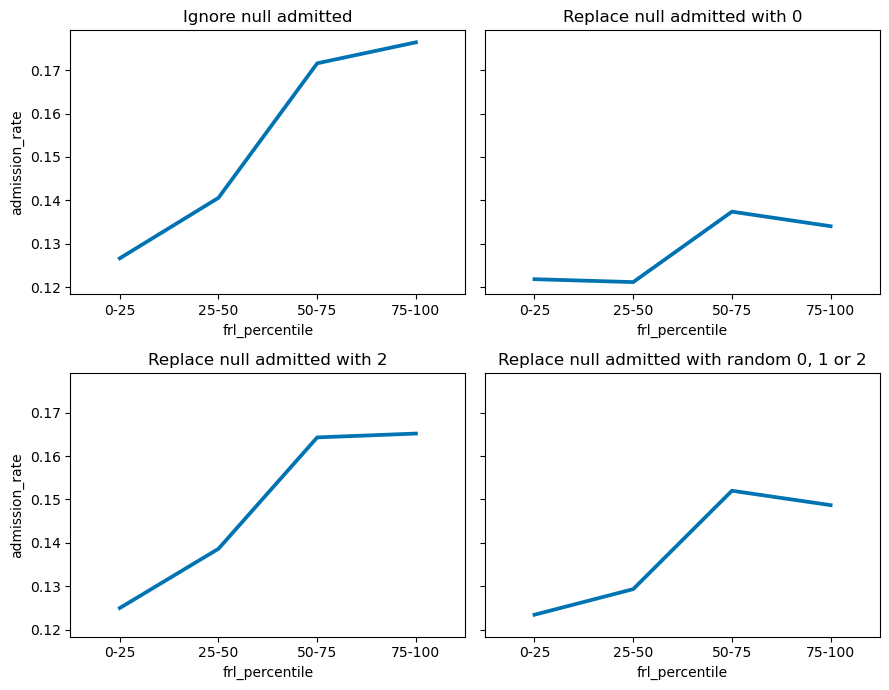

In [28]:
#| fig-alt: Four line plots in a 2-by-2 grid that share one y-axis, each showing the admission rate across the four FRL-percentile buckets under one way of handling null admit counts. Ignoring nulls gives 0.127, 0.141, 0.172 and 0.176; replacing them with 0 gives 0.122, 0.121, 0.137 and 0.134; replacing them with 2 gives 0.125, 0.139, 0.164 and 0.165; replacing them with a random 0, 1 or 2 gives 0.123, 0.129, 0.152 and 0.149. In every panel the two highest buckets sit above 0-25; the rise is steepest when nulls are ignored and flattest when they are replaced with 0.
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharey=True)
panels = [
    (axes[0, 0], "Ignore null admitted", ignore_rates),
    (axes[0, 1], "Replace null admitted with 0", replace_0_rates),
    (axes[1, 0], "Replace null admitted with 2", replace_2_rates),
    (axes[1, 1], "Replace null admitted with random 0, 1 or 2", random_rates),
]
for ax, title, rates in panels:
    sns.pointplot(rates, x="frl_percentile", y="admission_rate", order=["0-25", "25-50", "50-75", "75-100"], marker="", ax=ax)
    ax.set_title(title)
plt.tight_layout();

The pattern in admission rates is somewhat sensitive to our choice. In every version, the two highest-FRL buckets, `50-75` and `75-100`, admit at a higher rate than `0-25`, so that part of the pattern is stable. How large the gap is depends on the choice. The `75-100` rate ranges from 0.134 when the nulls become 0 to 0.176 when we ignore them, while the `0-25` rate only moves between 0.122 and 0.127. Even the first step is not stable: replacing the nulls with 0 puts `25-50` (0.121) just below `0-25` (0.122), and the other three options put it above.

The reason is where the nulls are. Here they are counted by bucket, with `.null_count()` as an expression inside `.agg()`:

In [29]:
binned.group_by("frl_percentile").agg(
    null_admitted=pl.col("admitted").null_count(),
    num_schools=pl.len(),
).sort("frl_percentile")

frl_percentile,null_admitted,num_schools
str,u32,u32
"""0-25""",49,294
"""25-50""",108,293
"""50-75""",116,293
"""75-100""",118,293


Only 49 of the 294 schools in `0-25` have a null admit count, against 108 to 118 in each of the other buckets. The more nulls a bucket holds, the more its rate depends on what we put in their place.

We can say more. Every null stands for 0, 1 or 2, so replacing the nulls with 0 and replacing them with 2 give the lowest and the highest rate that the true counts could produce. The true rate of each bucket lies somewhere between those two lines. Ignoring the nulls lands *above* the fill-with-2 line in all four buckets (0.176 against 0.165 in `75-100`, for example), outside the range the truth can occupy. The schools that option drops are exactly the ones that admitted at most 2 students each. Even if every one of them had admitted 2, their combined admission rate would be lower than that of the schools we kept, so leaving them out pushes each bucket's rate too high.

Random imputation stays inside the range by construction, since each null becomes 0, 1 or 2. We use it as our working choice from here on, remembering that the size of the gap between buckets depends on it.

### Admission Rates Move the Other Way

Here are the application rates and the admission rates, with random imputation, side by side:

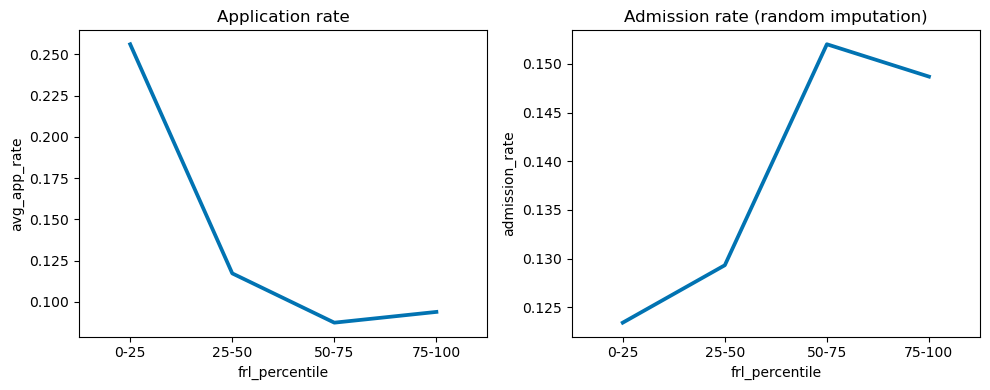

In [30]:
#| fig-alt: Two line plots side by side across the four FRL-percentile buckets. On the left, the application rate falls from 0.256 at 0-25 to 0.117 and then 0.087, and rises slightly to 0.094 at 75-100. On the right, the admission rate with random imputation rises from 0.123 at 0-25 to 0.129 and then 0.152, and dips slightly to 0.149 at 75-100.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.pointplot(app_by_frl, x="frl_percentile", y="avg_app_rate", order=["0-25", "25-50", "50-75", "75-100"], marker="", ax=axes[0])
axes[0].set_title("Application rate")
sns.pointplot(random_rates, x="frl_percentile", y="admission_rate", order=["0-25", "25-50", "50-75", "75-100"], marker="", ax=axes[1])
axes[1].set_title("Admission rate (random imputation)")
plt.tight_layout();

The two panels have different y-axis scales, so this figure compares the direction of each pattern, not its size.

Admission rates have a different pattern than application rates. As the share of students who qualify for free or reduced-price meals rises, application rates fall, from 0.256 in `0-25` to 0.094 in `75-100`. Admission rates move the other way, from 0.123 to 0.129, 0.152 and 0.149. Students at high-FRL schools apply to Berkeley at lower rates, but those who apply are admitted at higher rates.

What could be going on here? We will investigate in the next chapter.